In [1]:
import os
import scipy

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [6]:
dir_train = 'perros/train'
dir_test = 'perros/test'
size = (100, 100)

In [7]:
trdata = ImageDataGenerator()
train_data = trdata.flow_from_directory(directory = dir_train, target_size = size)

Found 2479 images belonging to 22 classes.


In [8]:
tsdata = ImageDataGenerator()
test_data = trdata.flow_from_directory(directory = dir_test, target_size = size)

Found 308 images belonging to 22 classes.


In [11]:
def create_model():
    opt = Adam(lr = 0.001)
    model = Sequential()
    model.add(Conv2D(input_shape=(100,100,3),filters=64,kernel_size=(5,5), padding="same", activation="relu"))
    #model.add(Conv2D(filters=64,kernel_size=(3,3),padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))  
    
    #model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
    #model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
    
    model.add(Conv2D(filters=128, kernel_size=(5,5), padding="same", activation="relu")) #, padding="same"
    #model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
    
    model.add(Conv2D(filters=256, kernel_size=(5,5), padding="same", activation="relu"))
    #model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
    #model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
    
    model.add(Conv2D(filters=512, kernel_size=(5,5), padding="same", activation="relu"))
    #model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
    #model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(11,11),strides=(2,2)))
    
    #model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
    #model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
    #model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
    #model.add(MaxPooling2D(pool_size=(5,5),strides=(2,2)))

    model.add(Flatten())
    
    
    model.add(Dense(units=512,activation="relu"))
    model.add(Dense(units=128,activation="relu"))
    model.add(Dense(units=22, activation="softmax"))
    
    model.compile(optimizer=opt, loss=tf.keras.losses.categorical_crossentropy, metrics=['accuracy'])
    
    return model

In [12]:
model = create_model()
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 100, 100, 64)      4864      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 50, 50, 64)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 50, 50, 128)       204928    
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 25, 25, 128)       0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 25, 25, 256)       819456    
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 12, 12, 256)       0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 12, 12, 512)      

In [13]:
checkpoint = ModelCheckpoint("vgg16.h5", 
                             monitor='val_acc', 
                             verbose=1, save_best_only=True, 
                             save_weights_only=False, mode='auto', period=1)

early = EarlyStopping(monitor='val_acc', min_delta=0, 
                      patience=5, verbose=1, mode='auto')

In [ ]:
hist = model.fit_generator(steps_per_epoch = 50,
                           generator = train_data, 
                           validation_data = test_data, 
                           validation_steps = 5,
                           epochs = 20,
                           callbacks = [checkpoint,early])

Epoch 1/20
 5/50 [==>...........................] - ETA: 5s - loss: 2.6500 - acc: 0.1813
Epoch 00001: val_acc did not improve from 0.18125
50/50 [==============================] - 6s 113ms/step - loss: 2.5838 - acc: 0.2129 - val_loss: 2.6500 - val_acc: 0.1813
Epoch 2/20
 5/50 [==>...........................] - ETA: 5s - loss: 2.6770 - acc: 0.2125
Epoch 00002: val_acc improved from 0.18125 to 0.21250, saving model to vgg16.h5
50/50 [==============================] - 5s 107ms/step - loss: 2.4707 - acc: 0.2250 - val_loss: 2.6770 - val_acc: 0.2125
Epoch 3/20
 5/50 [==>...........................] - ETA: 5s - loss: 2.4172 - acc: 0.2938
Epoch 00003: val_acc improved from 0.21250 to 0.29375, saving model to vgg16.h5
50/50 [==============================] - 5s 106ms/step - loss: 2.4491 - acc: 0.2489 - val_loss: 2.4172 - val_acc: 0.2938
Epoch 4/20
 5/50 [==>...........................] - ETA: 5s - loss: 2.8615 - acc: 0.2000
Epoch 00004: val_acc did not improve from 0.29375
50/50 [==============

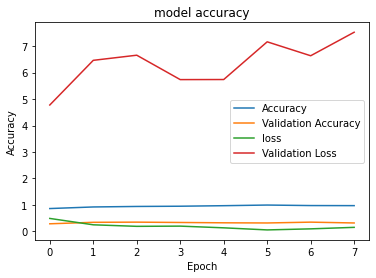

In [209]:
plt.plot(hist.history["acc"])
plt.plot(hist.history['val_acc'])
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","Validation Accuracy","loss","Validation Loss"])
plt.show()

In [5]:
saved_model = load_model("vgg16.h5")

In [6]:
path = r"C:\Users\brick\Downloads\dog\test"
images = os.listdir(path)
categories = os.listdir(r"C:\Users\brick\Downloads\dog\perros\test")

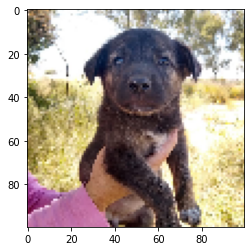

[2, 12, 21, 14, 19, 0, 10, 11, 1, 18, 20, 9, 4, 15, 8, 7, 17, 16, 6, 13, 5, 3]
Airedale terrier 93.22318434715271
Dachshund 6.375541538000107
Pug 0.2644229447469115
Doberman Pinscher 0.03742910921573639
Labrador Retriever 0.03494678530842066


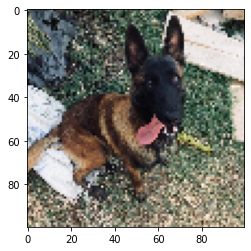

[16, 8, 2, 14, 12, 21, 18, 0, 11, 9, 1, 13, 17, 4, 19, 15, 10, 5, 7, 20, 6, 3]
German Shepherd Dog 54.08427715301514
Belgian Malinois 42.14952886104584
Airedale terrier 0.981595367193222
Doberman Pinscher 0.8276700042188168
Dachshund 0.616365484893322


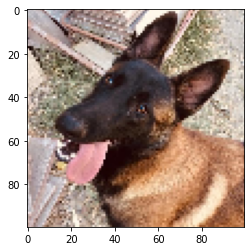

[21, 16, 2, 8, 12, 17, 19, 13, 11, 18, 14, 1, 5, 9, 4, 15, 0, 20, 7, 6, 10, 3]
Pug 90.79700112342834
German Shepherd Dog 6.4698852598667145
Airedale terrier 1.7877331003546715
Belgian Malinois 0.38817788008600473
Dachshund 0.3115435363724828


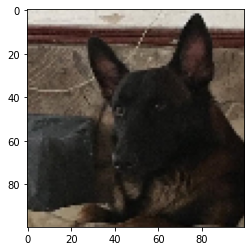

[16, 14, 19, 15, 2, 9, 4, 18, 17, 7, 12, 8, 5, 13, 1, 21, 0, 10, 11, 20, 6, 3]
German Shepherd Dog 93.79177689552307
Doberman Pinscher 2.243945188820362
Labrador Retriever 1.057199202477932
French Bulldog 0.7917462848126888
Airedale terrier 0.6440527737140656


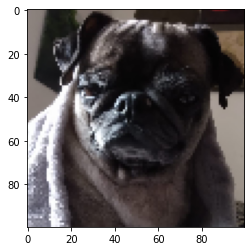

[21, 18, 7, 4, 12, 14, 20, 2, 11, 5, 15, 1, 6, 16, 0, 10, 9, 19, 17, 3, 8, 13]
Pug 42.57502853870392
Great Dane 12.958554923534393
Australian Sheperd 12.647539377212524
Akita 7.060620933771133
Dachshund 6.708471477031708


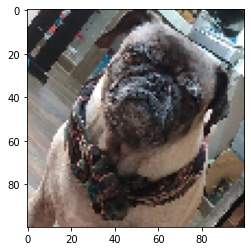

[2, 21, 8, 19, 12, 7, 16, 9, 15, 10, 11, 20, 18, 1, 0, 17, 14, 13, 4, 6, 5, 3]
Airedale terrier 54.86340522766113
Pug 43.381160497665405
Belgian Malinois 0.6103114690631628
Labrador Retriever 0.335884396918118
Dachshund 0.20081596449017525


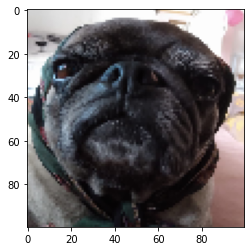

[2, 1, 0, 12, 11, 21, 19, 14, 20, 18, 10, 8, 6, 7, 9, 15, 16, 4, 17, 13, 5, 3]
Airedale terrier 77.35123038291931
Afghan hound 8.225067704916
Affenpinscher 5.802924931049347
Dachshund 4.3728057295084
Cocker Spaniel 1.5185533091425896


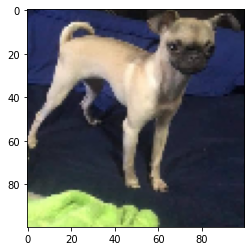

[14, 9, 1, 18, 16, 4, 15, 2, 11, 13, 10, 17, 3, 12, 21, 5, 8, 7, 0, 19, 20, 6]
Doberman Pinscher 76.99648141860962
Bull Terrier 9.3851238489151
Afghan hound 5.722067132592201
Great Dane 3.608638420701027
German Shepherd Dog 3.5209018737077713


In [7]:
for img in images:
    img_ = image.load_img(os.path.join(path,img),target_size=(100,100))
    img_ = np.asarray(img_)
    plt.imshow(img_)
    plt.show()
    img_ = np.expand_dims(img_, axis=0)
    
    pred = saved_model.predict(img_)
    
    list_index = [n for n in range(22)]
    P = pred 
    for i in range(22):
        for j in range(22):
            if P[0][list_index[i]] > P[0][list_index[j]]:
                temp = list_index[i]
                list_index[i] = list_index[j]
                list_index[j] = temp
            
    print(list_index)
    
    for i in range(5):
        print(categories[list_index[i]], P[0][list_index[i]]*100)